## standard BO exploration
- Input:
    - 需输入增强后的数据集  
    - random-search--times中迭代文件中的前十次随机探索的历史数据  
- 由于kaggle允许最长运行12h， 因此standard BO的15次探索分成了两次运行， 首次运行7次sbo探索，二次运行8次sbo探索  

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import time
import shutil
import pathlib
import itertools
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
import tensorflow_probability as tfp # TensorFlow Probability 的分布模块
tfd = tfp.distributions

#导入深度学习架构
from tensorflow import keras
from keras import models, optimizers, metrics, layers, regularizers, losses
from keras.models import Sequential
from keras.optimizers import SGD, RMSprop, Adam, Adagrad
import json

def set_reproducibility(seed=88):
    """
    设置一个全局种子来确保整个实验流程的可复现性。
    这包括Python内置random、os、NumPy和TensorFlow。
    """
    # Python 内置的 random 模块的种子
    random.seed(seed)
    
    # os 环境变量 PYTHONHASHSEED
    # 这可以防止hash碰撞，使得字典等hash操作在不同运行间保持一致
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy 的随机种子,考虑到数据预处理和初始化依赖于NumPy
    np.random.seed(seed)
    
    # TensorFlow 的全局随机种子，控制模型权重初始化、Dropout、随机数据增强等
    tf.random.set_seed(seed)
    
    # 强制 TensorFlow 使用确定性的、单线程的操作
    tf.config.experimental.enable_op_determinism()
    
    print(f"全局随机种子设置为: {seed}，并已启用TensorFlow确定性操作。")

SEED_VALUE = 88 
set_reproducibility(SEED_VALUE)

2026-03-21 01:39:35.351227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774057175.547805      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774057175.600600      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ 全局随机种子已设置为: 88，并已启用TensorFlow确定性操作。


In [ ]:
# kaggle中数据集会自动解压缩，只需要直接讲数据加载到output中

import matplotlib.image as img

'''加载到output路径并划分文件夹'''

!pip install split-folders -q
import splitfolders
input_dir="/kaggle/input/augmented-alzheimer-data/augmented_data"
output_dir="./output"
splitfolders.ratio(
    input_dir, 
    output=output_dir, 
    seed=1345, 
    ratio=(.70, 0.15,0.15),
    group_prefix=None #保持原始目录结构分层分割，确保每个类别都按相同比例分割
) 
print("Dataset split completed!")

#验证输出路径文件夹文件数量
def count_files(directory):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(directory, split)
        print(f"\n{split.upper()} set:")
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            num_files = len(os.listdir(class_path))
            print(f"  {class_name}: {num_files} images")

count_files("./output")

AUTOTUNE = tf.data.AUTOTUNE

IMG_HEIGHT = 224
IMG_WIDTH = 224 
batch_size=32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/train",
seed=123,
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=True
).prefetch(buffer_size=AUTOTUNE)
# 默认情况下label_mode='int'后续匹配sparse_categorical_crossentropy	需设置from_logits=True/False


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/test",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False  
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/val",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False
).prefetch(buffer_size=AUTOTUNE)

Copying files: 12800 files [00:59, 213.62 files/s]


Dataset split completed!

TRAIN set:
  MildDemented: 2240 images
  NonDemented: 2240 images
  ModerateDemented: 2240 images
  VeryMildDemented: 2240 images

VAL set:
  MildDemented: 480 images
  NonDemented: 480 images
  ModerateDemented: 480 images
  VeryMildDemented: 480 images

TEST set:
  MildDemented: 480 images
  NonDemented: 480 images
  ModerateDemented: 480 images
  VeryMildDemented: 480 images
Found 8960 files belonging to 4 classes.


I0000 00:00:1774057258.197828      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774057258.200649      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1920 files belonging to 4 classes.
Found 1920 files belonging to 4 classes.


In [ ]:
import os, random, time, gc, json
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import tensorflow as tf, tensorflow_probability as tfp
from tensorflow import keras
from keras import layers, regularizers
import scipy.stats as stats
tfd = tfp.distributions
sns.set_style('whitegrid')
tf.keras.backend.set_floatx('float64')

#-----------------------------模型架构搭建：顺序模型------------------------------
def build_pretrained_model(hparams):
    # 加载预训练的EfficientNet，不包含顶部的分类层
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    # 冻结预训练模型的权重
    base_model.trainable = False
    
    # 确定从哪个块开始解冻（微调）
    fine_tune_at_block = 'block5a_expand_conv'
    # 遍历所有层，解冻 fine_tune_at_block 及之后的所有层
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == fine_tune_at_block:
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    # 无论是否解冻，都保持 BatchNormalization 层处于冻结状态
    # 在微调时，用小批量数据更新BN层的统计数据可能会引入噪声，破坏预训练学到的分布
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    
    dense_units = int(hparams.get('dense_units', 128))
    dropout_rate = hparams.get('dropout_rate', 0.5)
    l2_reg = hparams.get('l2_reg', 0.001)
    lr = hparams.get('lr', 0.0001)
    optimizer_choice = int(hparams.get('optimizer_choice', 0))
    momentum = hparams.get('momentum', 0.9)
    
    # 在预训练模型之上，构建一个分类头
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # 使用全局平均池化替代Flatten，参数更少，不易过拟合
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)), # 使用更小的L2值
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax') # 4个类别
    ])

    if optimizer_choice == 0:
        print("--- 使用 Adam 优化器 ---")
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == 1:
        print(f"--- 使用 SGD 优化器 (momentum={momentum:.3f}) ---")
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    elif optimizer_choice == 2:
        print("--- 使用 RMSprop 优化器 ---")
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    elif optimizer_choice ==3:
        print("--- 使用 Adagrad 优化器 ---")
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr)
    else: # optimizer_choice == 分数
        print("--- 无法找到对应的优化器，请检查optimizer_choice value ---")
        
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
   
    return model


class TrainingCallback(keras.callbacks.Callback):
    def __init__(self, epochs):
        super().__init__()
        self.epochs = epochs
    def on_train_begin(self, logs=None):
        header = "{0:^8s}{1:^11s}{2:^11s}{3:^12s}{4:^12s}{5:^12s}".format('Epoch', 'Loss', 'Acc', 'Val_Loss', 'Val_Acc', 'Duration')
        print(header)
    def on_epoch_begin(self, epoch, logs=None): 
        self.ep_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.ep_start
        acc = logs.get('accuracy', 0); val_acc = logs.get('val_accuracy', 0)
        loss = logs.get('loss', 0); val_loss = logs.get('val_loss', 0)
        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^10.3f}{acc * 100:^11.3f}{val_loss:^12.5f}{val_acc * 100:^12.3f}{duration:^12.2f}'
        print(msg)
        

def train_and_evaluate_model(hparams,train_ds,val_ds,epochs=30):
    # 创建模型
    model = build_pretrained_model(hparams) 
    
    training_callback = TrainingCallback(
        epochs=epochs
    )
    
    early_stopping_callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,  # 验证集准确率连续5个epoch没有提升就停止
        min_delta=0.005,
        restore_best_weights=True, # 关键：自动恢复到性能最好的那个epoch的权重
        verbose=0 # 在BO循环中保持安静
    )
    
    #训练模型
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=0,
        callbacks=[training_callback,early_stopping_callback]
    )

    loss, accuracy = model.evaluate(val_ds, verbose=0)
    # 从早停回调中获取最佳轮次信息
    best_epoch_num = early_stopping_callback.best_epoch + 1
    print(f"  > 训练评估完成: Best Val Acc: {accuracy:.4f}, 对应的 Loss:{loss:.4f}(at epoch {best_epoch_num})")
    
    return accuracy

In [ ]:
# 自定义贝叶斯优化器
class BayesianOptimizer:
    def __init__(self, search_space, init_points=5, exploration=0.01, 
                 log_file="custom_bo_log.json", initial_X=None, initial_y=None):
        self.search_space = np.array(search_space)
        self.dim = len(search_space)
        self.init_points = init_points
        self.exploration = exploration
        self.log_file = log_file
        # 以防训练由于超时中断,设置自断点处接着SBO迭代,加载已计算好的数据
        if initial_X is not None and initial_y is not None:
            self.X_obs = initial_X
            self.y_obs = initial_y
            print(f"BO optimizer has used {len(self.y_obs)} observed datas to initialize")
            #日志回填
            print(f"new log '{self.log_file}' is set and loads old data into it ")
            if os.path.exists(self.log_file):
                os.remove(self.log_file)
            for i in range(len(self.y_obs)):
                self._write_log(iteration=i + 1, x_new=self.X_obs[i], y_new=self.y_obs[i])
            print(f"历史数据回填完成。共写入 {len(self.y_obs)} 条记录。")
        else: 
            self.X_obs = np.zeros((0, self.dim))
            self.y_obs = np.zeros(0)
            if os.path.exists(self.log_file):
                os.remove(self.log_file)
                
        self.theta_dim = self.dim + 2 # length_scales (dim) + amplitude + noise
        
        self.num_samples = 20
        self.burn_in = 100
        
    
    def random_sample(self):
        """在搜索空间内随机采样一个超参数点。"""
        return np.array([np.random.uniform(low, high) for (low, high) in self.search_space])

    @tf.function(jit_compile=True) # 使用XLA编译加速
    def matern52_kernel(self, X1, X2, theta):
        # theta=(lenthscale,sigma_f,sigma_n),sigma_d就是amplitude
        X1_tf = tf.cast(X1, tf.float64)
        X2_tf = tf.cast(X2, tf.float64)
        theta = tf.cast(theta, tf.float64)
        
        length_scales = theta[:self.dim]
        amplitude = theta[self.dim]
        
        X1_scaled = X1_tf / length_scales
        X2_scaled = X2_tf / length_scales

        # 为了高效计算，我们使用广播机制
        r2 = tf.reduce_sum(tf.square(X1_scaled), axis=1, keepdims=True) - 2 * tf.matmul(X1_scaled, X2_scaled, transpose_b=True) + tf.reduce_sum(tf.square(X2_scaled), axis=1)
        # 确保 r2 不为负数
        r2 = tf.maximum(r2, 1e-12)
        r = tf.sqrt(r2)
        
        five_64 = tf.constant(5.0, dtype=tf.float64)
        three_64 = tf.constant(3.0, dtype=tf.float64)
        one_64 = tf.constant(1.0, dtype=tf.float64)
        sqrt5_64 = tf.sqrt(five_64)
        
        term = (one_64 + sqrt5_64 * r + (five_64 / three_64) * r2) * tf.exp(-sqrt5_64 * r)
        
        K = amplitude**2 * term
        return K

    
    @tf.function(jit_compile=True) # 使用XLA编译加速
    def log_posterior(self, theta, X, y):
        # 计算log(P(y | X, theta))这是因为原本要算的P(θ∣X,y)∝P(y∣X,θ)×P(θ)
        #而先验 P(theta)由于我们一无所知所以是一个均匀分布,那么最大化theta后验等价于最大化似然
        # 因而这里是在求max log(y|X,theta)
        f64 = tf.constant(1e-6, dtype=tf.float64)
        two_pi_64 = tf.constant(2.0 * np.pi, dtype=tf.float64)
        half_64 = tf.constant(0.5, dtype=tf.float64)
        
        X_tf = tf.cast(X, dtype=tf.float64)
        y_tf = tf.cast(y, dtype=tf.float64)
        theta_tf = tf.cast(theta, dtype=tf.float64)
        
        noise = theta_tf[self.dim + 1]**2
        
        K = self.matern52_kernel(X_tf, X_tf, theta_tf)
        n = tf.shape(K)[0]
        K += (noise + f64) * tf.eye(n, dtype=tf.float64)
        
        L = tf.linalg.cholesky(K)
        alpha = tf.linalg.cholesky_solve(L, tf.expand_dims(y_tf, 1))
        
        log_lik = -half_64 * tf.squeeze(tf.matmul(tf.expand_dims(y_tf, 0), alpha))
        log_lik -= tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
        n_64 = tf.cast(n, tf.float64)
        log_lik -= half_64 * n_64 * tf.math.log(two_pi_64)
        
        return log_lik


    def sample_theta_posterior(self):
        def target_log_prob_fn(theta):
            return self.log_posterior(theta, self.X_obs, self.y_obs)

        kernel = tfp.mcmc.HamiltonianMonteCarlo(
            target_log_prob_fn=target_log_prob_fn,
            num_leapfrog_steps=3,
            step_size=0.1)
        
        samples = tfp.mcmc.sample_chain(
            num_results=self.num_samples,
            current_state=tf.ones(self.theta_dim, dtype=tf.float64),
            kernel=kernel,
            num_burnin_steps=self.burn_in,
            trace_fn=None)
        
        return samples.numpy()
    
    def expected_improvement(self, x_candidate, theta_samples):
        if self.y_obs.size == 0: return 1.0
        
        y_best = np.max(self.y_obs)
        x_candidate_reshaped = x_candidate.reshape(1, -1)
        
        ei_values = []
        for theta in theta_samples:

            try:
                # 将theta转为numpy，因为下面的计算在numpy中进行
                theta_np = theta.numpy() if hasattr(theta, 'numpy') else theta
                
                K_obs = self.matern52_kernel(self.X_obs, self.X_obs, theta_np).numpy()
                noise = theta_np[self.dim + 1]**2
                K_obs += (noise + 1e-6) * np.eye(len(self.X_obs))
                
                K_cross = self.matern52_kernel(self.X_obs, x_candidate_reshaped, theta_np).numpy()
                K_candidate = self.matern52_kernel(x_candidate_reshaped, x_candidate_reshaped, theta_np).numpy()
                L = np.linalg.cholesky(K_obs)
                L_inv_K_cross = np.linalg.solve(L, K_cross)
                
                mu = np.dot(L_inv_K_cross.T, np.linalg.solve(L, self.y_obs))
                sigma2 = K_candidate - np.dot(L_inv_K_cross.T, L_inv_K_cross)

                # mu 是 (1,) 形状的一维数组, 用 [0] 提取
                mu_scalar = mu[0]
                # sigma2 是 (1,1) 形状的二维数组, 用 [0,0] 提取
                sigma2_scalar = sigma2[0, 0]
                
                sigma = np.sqrt(np.maximum(sigma2_scalar, 1e-9))
                # 如果 sigma 过小，则此点没有不确定性，EI为0
                if sigma == 0.0:
                    continue

                z = (mu_scalar - y_best - self.exploration) / sigma
                
                norm = stats.norm(loc=0, scale=1)
                ei = (mu_scalar - y_best - self.exploration) * norm.cdf(z) + sigma * norm.pdf(z)
                
                # 确保 ei 是一个正常的浮点数
                if not np.isnan(ei):
                    ei_values.append(ei)

            except np.linalg.LinAlgError:
                # 矩阵计算出错时跳过此样本
                print("警告: 在EI计算中发生矩阵奇异值错误，跳过此theta样本。")
                continue
                
        return np.mean(ei_values) if ei_values else 0.0
         

    def _write_log(self, iteration, x_new, y_new):
        param_names = ['lr','dense_units','dropout_rate','l2_reg','optimizer_choice','momentum']
        params_dict = {name:val for name, val in zip(param_names, x_new)}
        log_entry={'iteration':int(iteration),
                   'accuracy':float(y_new),
                   'params':params_dict}
        with open(self.log_file,'a') as f: 
            f.write(json.dumps(log_entry)+'\n')
    
    def optimize(self, objective_fn, n_iter=30):
        #检查是 初次SBO 还是 接续SBO
        num_existing_points=self.X_obs.shape[0]
        num_init_points_to_run = max(0, self.init_points - num_existing_points)

        if num_init_points_to_run > 0:
            # 加载的点数少于要求的初始随机化点数，需要补充运行
            print(f"--- 继续随机初始化阶段: 还需要运行 {num_init_points_to_run} 个初始点。 ---")
            for i in range(num_init_points_to_run):
                print(f"\n--- 初始点 {num_existing_points + i + 1}/{self.init_points} ---")
                x_new = self.random_sample()
                y_new = objective_fn(x_new)
                self.X_obs = np.vstack([self.X_obs, x_new])
                self.y_obs = np.append(self.y_obs, y_new)
                self._write_log(iteration=num_existing_points + i + 1, x_new=x_new, y_new=y_new)
        
        elif num_existing_points > 0:
            # 成功恢复运行。加载的点数已满足要求，跳过随机搜索。
            print(f"--- 成功恢复优化: 已加载 {num_existing_points} 个点。跳过 {self.init_points} 个初始点的随机搜索阶段。 ---")
        
        else:
            # 全新运行 (没有加载任何数据)
            print(f"--- 开始全新运行: 执行 {self.init_points} 个初始随机点 ---")
            for i in range(self.init_points):
                print(f"\n--- 初始点 {i + 1}/{self.init_points} ---")
                x_new = self.random_sample()
                y_new = objective_fn(x_new)
                self.X_obs = np.vstack([self.X_obs, x_new])
                self.y_obs = np.append(self.y_obs, y_new)
                self._write_log(iteration=i + 1, x_new=x_new, y_new=y_new)

        print(f"\n--- 开始执行 {n_iter} 次新的贝叶斯优化迭代 ---")

        
        for i in range(n_iter):
            print(f"\n--- 优化迭代 {i+1}/{n_iter} ---")
            
            theta_samples = self.sample_theta_posterior()
            
            best_ei = -1
            best_x = None
            for _ in range(200): # 增加随机搜索次数以更好地优化采集函数
                x_candidate = self.random_sample()
                ei = self.expected_improvement(x_candidate, theta_samples)
                if ei > best_ei:
                    best_ei = ei
                    best_x = x_candidate
            
            if best_x is None:
                print("警告：无法找到有效的候选点，将进行随机采样。")
                best_x = self.random_sample()

            y_new = objective_fn(best_x)
            
            self.X_obs = np.vstack([self.X_obs, best_x])
            self.y_obs = np.append(self.y_obs, y_new)
            # 在每次优化后也写入日志
            new_iteration_number = self.X_obs.shape[0]
            self._write_log(iteration=new_iteration_number, x_new=best_x, y_new=y_new)

        best_idx = np.argmax(self.y_obs)
        return self.X_obs[best_idx], self.y_obs[best_idx]

In [ ]:
class StandardBayesianOptimizer(BayesianOptimizer):
    def __init__(self, search_space, init_points=5, exploration=0.01, 
                 log_file="standard_bo_log.json", initial_X=None, initial_y=None):
        super().__init__(search_space, init_points, exploration, log_file, initial_X, initial_y)

    def get_best_theta(self, num_restarts=5, num_steps=100):
        """
        通过多起点梯度下降（Multi-start Gradient Descent）
        找到使 Log Posterior 最大的单一 Theta (MAP估计)，避免陷入局部最优。
        """
        best_theta = None
        best_log_post = -np.inf

        # 进行多次随机重启，寻找全局（或更好的局部）最优解
        for restart in range(num_restarts):
            # 使用均匀分布在正数区间初始化，避免负数问题
            initial_theta = tf.random.uniform([self.theta_dim], minval=0.1, maxval=2.0, dtype=tf.float64)
            theta_var = tf.Variable(initial_theta)

            # 每次重启创建一个独立的优化器
            local_optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)
            
            # 梯度下降循环
            for _ in range(num_steps):
                with tf.GradientTape() as tape:
                    # 使用 tf.math.softplus 保证输入到核函数的超参数严格为正
                    # 这是处理 GP 超参数的数学惯例
                    positive_theta = tf.math.softplus(theta_var)
                    loss = -self.log_posterior(positive_theta, self.X_obs, self.y_obs)
                
                grads = tape.gradient(loss, [theta_var])
                local_optimizer.apply_gradients(zip(grads, [theta_var]))

            # 评估本次重启收敛后的结果
            final_positive_theta = tf.math.softplus(theta_var)
            current_log_post = self.log_posterior(final_positive_theta, self.X_obs, self.y_obs).numpy()

            # 记录最大后验的 theta
            if current_log_post > best_log_post and not np.isnan(current_log_post):
                best_log_post = current_log_post
                best_theta = final_positive_theta

        # 如果所有的重启都失败，退回均值初始化
        if best_theta is None:
            print("警告: 所有的 MAP 优化尝试都失败了，采用默认初始化。")
            best_theta = tf.ones(self.theta_dim, dtype=tf.float64)

        return [best_theta]

    def sample_theta_posterior(self):
        """
        覆盖父类的采样方法。返回优化后的单一 MAP 估计点。
        """
        if len(self.y_obs) > 0:
            return self.get_best_theta()
        else:
            return [tf.ones(self.theta_dim, dtype=tf.float64)]

In [ ]:
import time
import gc 

search_space = [
    (1e-5, 5e-4),    # lr
    (64, 512),       # dense_units
    (0.2, 0.7),      # dropout_rate
    (1e-5, 5e-3),    # l2_reg
    (0, 3.99),      # 0=Adam, 1=SGD, 2=RMSprop, 3=Adagrad
    (0.85, 0.99)     # momentum
]
#=============================================================================================
def my_objective_fn(x_new):
    # 将优化器给出的numpy数组转换为超参数字典
    hparams = {
        'lr': x_new[0],
        'dense_units': int(x_new[1]),
        'dropout_rate': x_new[2],
        'l2_reg': x_new[3],
        'optimizer_choice': int(x_new[4]),
        'momentum': x_new[5],
    }
    # 清理会话并调用训练函数
    tf.keras.backend.clear_session()
    gc.collect()
    print(f"\n正在评估超参数: {hparams}")
    accuracy = train_and_evaluate_model(hparams, train_ds, val_ds, epochs=40)
    print(f"评估完成 - 验证集准确率: {accuracy:.4f}")
    return accuracy

In [ ]:
#加载ver4的standard BO的共17条历史记录
log_file_path = "/kaggle/input/datasets/earthajasmine/standard-bo-ver4-data/standard_bo_map_v4_17.json" 

param_order=['lr', 'dense_units', 'dropout_rate', 'l2_reg', 'optimizer_choice', 'momentum']

num_init_to_load = 17 #加载前十次随机探索数据和7次standard BO数据
X_list = []
y_list = []
print(f"正在从已有的日志文件 '{log_file_path}' 中恢复进度...")
try:
    with open(log_file_path, 'r') as f:
        for line in f:
            if len(y_list) >= num_init_to_load:
                break
            line = line.strip()#去除日志每一条首尾的空白字符
            if not line: continue
            log_entry = json.loads(line)
            y_list.append(log_entry['accuracy'])
            params_dict = log_entry['params']
            X_list.append([params_dict[key] for key in param_order])

    initial_X = np.array(X_list)
    initial_y = np.array(y_list)

    print(f"✅ 成功恢复了 {len(initial_y)} 条记录。")
    print(f"   - initial_X 的形状: {initial_X.shape}")
    print(f"   - initial_y 的形状: {initial_y.shape}")

except FileNotFoundError:
    print(f"❌ 错误: 未找到日志文件，请检查路径: '{log_file_path}'")
    initial_X, initial_y = None, None

正在从已有的日志文件 '/kaggle/input/datasets/earthajasmine/standard-bo-ver4-data/standard_bo_map_v4_17.json' 中恢复进度...
✅ 成功恢复了 17 条记录。
   - initial_X 的形状: (17, 6)
   - initial_y 的形状: (17,)


In [ ]:
TARGET_INIT_POINTS = 10  # 计划的初始随机点数
TARGET_BO_ITERATIONS = 15 # 计划的BO迭代总数 

# 计算已完成和剩余的工作量 
if initial_X is not None:
    COMPLETED_TOTAL_POINTS = len(initial_y)
    # 已完成的BO迭代次数 = 总点数 - 初始点数
    COMPLETED_BO_ITERATIONS = max(0, COMPLETED_TOTAL_POINTS - TARGET_INIT_POINTS)
    # 剩余的BO迭代次数
    REMAINING_BO_ITERATIONS = max(0, TARGET_BO_ITERATIONS - COMPLETED_BO_ITERATIONS)

    print("\n" + "="*50)
    print("恢复运行计算:")
    print(f"  - 目标初始点数: {TARGET_INIT_POINTS}")
    print(f"  - 目标BO迭代次数: {TARGET_BO_ITERATIONS}")
    print("-" * 20)
    print(f"  - 已完成总点数: {COMPLETED_TOTAL_POINTS}")
    print(f"  - 已完成BO迭代: {COMPLETED_BO_ITERATIONS}")
    print(f"  - 剩余BO迭代: {REMAINING_BO_ITERATIONS}")
    print("="*50)

    # 实例化Standard 优化器并注入已有数据 
    optimizer = StandardBayesianOptimizer(
        search_space=search_space,
        init_points=TARGET_INIT_POINTS,
        log_file="standard_bo_map_v5_25.json", # 使用一个新日志文件名
        initial_X=initial_X,
        initial_y=initial_y
    )

    # 运行剩余的优化迭代
    if REMAINING_BO_ITERATIONS > 0:
        print(f"\n🚀 开始继续执行剩余的 {REMAINING_BO_ITERATIONS} 次贝叶斯优化迭代...")
        #optimizer.optimize返回的是一个Numpy数组
        best_x, best_y = optimizer.optimize(
            objective_fn=my_objective_fn, 
            n_iter=REMAINING_BO_ITERATIONS # 只运行剩余的次数
        )
        
    else:
        print("\n所有计划的迭代均已完成，无需继续运行。")

else:
    print("\n未能加载恢复数据，无法继续运行。")

print("\n" + "="*50); print("贝叶斯优化完成!")
print(f"最佳验证准确率: {best_y:.4f}")

param_names = ['lr', 'dense_units', 'dropout_rate', 'l2_reg', 'optimizer_choice', 'momentum']
best_hparams = {name: val for name, val in zip(param_names, best_x)}
best_hparams['dense_units'] = int(best_hparams['dense_units'])
best_hparams['optimizer_choice'] = int(best_hparams['optimizer_choice'])

print(f"最佳超参数: {best_hparams}")
print("="*50)


恢复运行计算:
  - 目标初始点数: 10
  - 目标BO迭代次数: 15
--------------------
  - 已完成总点数: 17
  - 已完成BO迭代: 7
  - 剩余BO迭代: 8
BO optimizer has used 17 observed datas to initialize
new log 'standard_bo_map_v5_25.json' is set and loads old data into it 
历史数据回填完成。共写入 17 条记录。

🚀 开始继续执行剩余的 8 次贝叶斯优化迭代...
--- 成功恢复优化: 已加载 17 个点。跳过 10 个初始点的随机搜索阶段。 ---

--- 开始执行 8 次新的贝叶斯优化迭代 ---

--- 优化迭代 1/8 ---


I0000 00:00:1774057261.437118      19 service.cc:148] XLA service 0x2626a870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774057261.437897      19 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774057261.437933      19 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774057261.542662      19 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1774057261.956939      19 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



正在评估超参数: {'lr': 9.195000351566943e-05, 'dense_units': 390, 'dropout_rate': 0.5932718718302488, 'l2_reg': 0.004816202104570056, 'optimizer_choice': 3, 'momentum': 0.930432164262492}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- 使用 Adagrad 优化器 ---
 Epoch     Loss        Acc      Val_Loss    Val_Acc     Duration  


E0000 00:00:1774057290.066127      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     4.326     28.002     4.17229      39.479      177.52   
 2 /40     4.192     36.004     4.08812      47.708      157.29   
 3 /40     4.114     41.049     4.00729      51.875      157.12   
 4 /40     4.044     44.978     3.93227      54.583      157.21   
 5 /40     3.988     47.065     3.87349      55.260      157.26   
 6 /40     3.940     49.431     3.82831      56.719      157.28   
 7 /40     3.898     50.770     3.79119      58.073      157.31   
 8 /40     3.862     52.154     3.75938      58.646      157.32   
 9 /40     3.830     53.817     3.73267      59.531      157.27   
10 /40     3.807     54.732     3.70785      60.677      157.27   
11 /40     3.789     55.022     3.68713      61.562      156.90   
12 /40     3.761     56.607     3.66536      62.344      157.21   
13 /40     3.736     57.835     3.64581      62.917      157.46   
14 /40     3.722     57.400     3.62782      63.594      157.28   
15 /40     3.702     58.281     3.61039      64.167      156.9

...

 1 /40     1.628     67.600     1.06870      78.490      187.87   
 2 /40     0.888     79.040     0.66121      82.865      158.71   
 3 /40     0.554     85.279     0.46359      86.094      158.79   
 4 /40     0.366     90.167     0.31589      91.458      158.85   
 5 /40     0.243     93.471     0.28356      91.719      158.55   
 6 /40     0.136     96.730     0.19597      94.427      158.63   
 7 /40     0.127     96.518     0.20531      93.646      158.97   
 8 /40     0.103     97.500     0.16865      95.000      158.56   
 9 /40     0.064     98.438     0.09650      97.656      158.72   
10 /40     0.067     98.304     0.11231      97.552      158.76   
11 /40     0.065     98.203     0.20280      93.802      158.69   
12 /40     0.081     97.946     0.10877      96.823      158.72   
13 /40     0.044     98.984     0.09513      97.500      158.85   
14 /40     0.041     98.917     0.08467      97.708      158.70   
  > 训练评估完成: Best Val Acc: 0.9766, 对应的 Loss:0.0965(at epoch 9)


E0000 00:00:1774086093.593799      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     2.889     44.442     2.63160      57.448      179.47   
 2 /40     2.596     58.516     2.46265      64.375      156.92   
 3 /40     2.476     63.884     2.38880      68.490      157.05   
 4 /40     2.402     67.042     2.32530      69.635      157.18   
 5 /40     2.350     68.951     2.27431      72.448      156.88   
 6 /40     2.309     70.871     2.24269      74.115      157.16   
 7 /40     2.263     72.299     2.20627      74.531      157.05   
 8 /40     2.232     73.315     2.17911      75.729      156.72   
 9 /40     2.209     73.996     2.14977      76.146      157.11   
10 /40     2.182     75.033     2.12952      77.240      157.04   
11 /40     2.157     76.060     2.11389      77.135      156.97   
12 /40     2.135     77.020     2.09216      78.281      157.06   
13 /40     2.112     77.723     2.07921      78.021      157.17   
14 /40     2.094     78.348     2.05927      78.906      157.12   
15 /40     2.074     78.772     2.04578      79.844      156.9

E0000 00:00:1774092426.146801      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     1.735     43.906     1.48963      58.229      180.15   
 2 /40     1.472     57.176     1.34438      63.021      156.59   
 3 /40     1.370     61.618     1.26706      67.135      156.90   
 4 /40     1.295     64.732     1.21395      69.740      156.86   
 5 /40     1.253     67.165     1.17444      70.729      156.83   
 6 /40     1.210     68.806     1.14451      71.771      156.50   
 7 /40     1.178     70.480     1.12356      72.552      156.82   
 8 /40     1.157     71.205     1.10393      73.333      156.95   
 9 /40     1.143     72.031     1.09186      74.583      156.86   
10 /40     1.115     73.337     1.07314      74.896      156.88   
11 /40     1.105     73.382     1.05509      75.677      156.87   
12 /40     1.083     74.487     1.04712      76.302      156.80   
13 /40     1.071     74.911     1.02906      76.667      156.85   
14 /40     1.057     75.971     1.01902      77.396      156.44   
15 /40     1.034     77.411     1.01063      78.021      156.7

✅ Log file 'standard_bo_map_v5_25.json' loaded successfully! Loaded 25 evaluation records.

最终优化数据:
- 全局最优Val Accuracy:                 0.9807
- 探索阶段的最优Val Accuracy :  0.9750
- Absolute Improvement from Bayesian Opt: +0.0057 points
- Relative Improvement from Bayesian Opt: +0.59%


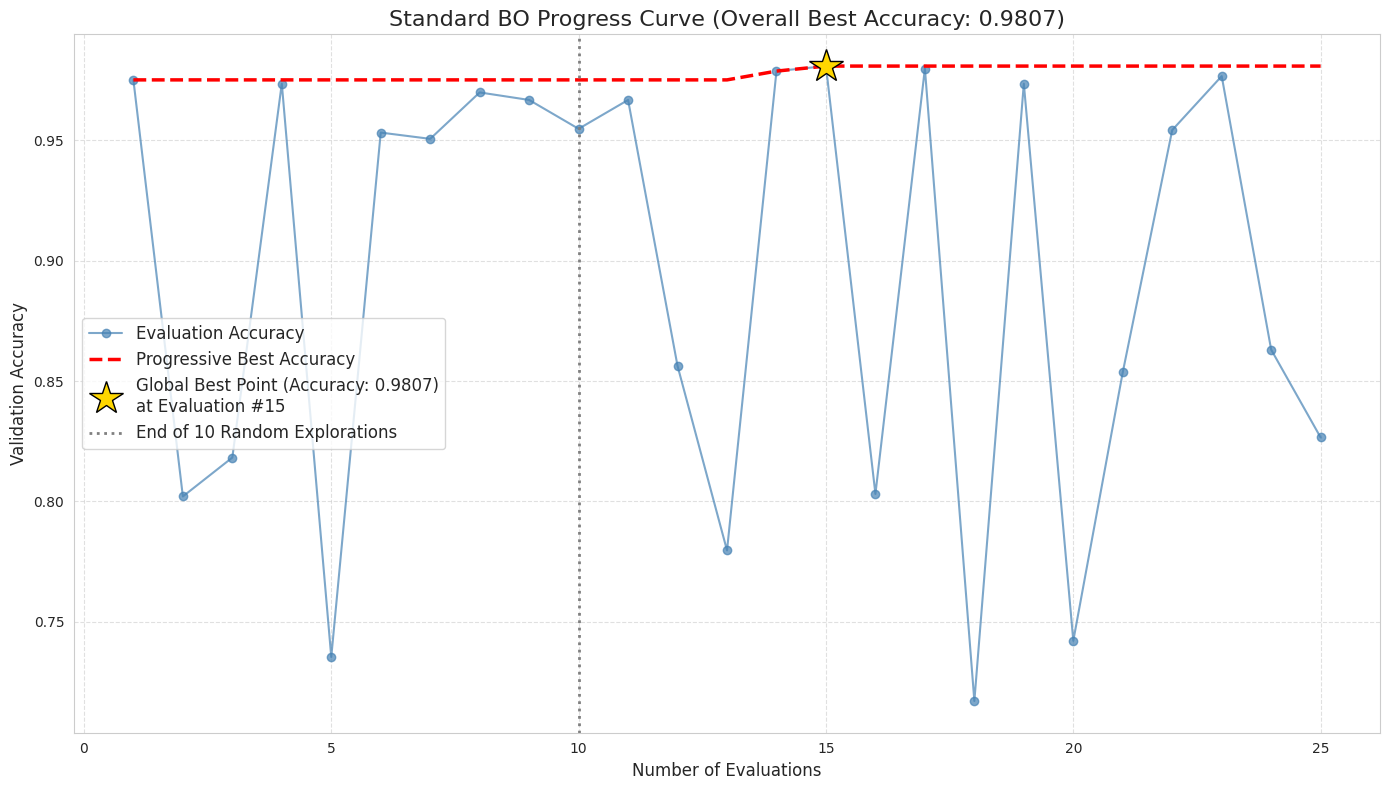

In [ ]:
# ===================================================================
# Standard贝叶斯优化全过程的图像表示
# ===================================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

log_file_path = "standard_bo_map_v5_25.json" 
initial_points = 10 

try:
    with open(log_file_path, 'r') as f:
        logs = [json.loads(line) for line in f]
    
    df_results = pd.DataFrame(logs)
    all_accuracies = df_results['accuracy'].values
    print(f"✅ Log file '{log_file_path}' loaded successfully! Loaded {len(all_accuracies)} evaluation records.")
    
    if len(all_accuracies) > initial_points:
        accuracies_in_init_phase = all_accuracies[:initial_points]
        best_random_accuracy = np.max(accuracies_in_init_phase)
        best_final_accuracy = np.max(all_accuracies)
        absolute_improvement = best_final_accuracy - best_random_accuracy
        
        print("\n" + "="*50)
        print("最终优化数据:")
        print("="*50)
        print(f"- 全局最优Val Accuracy:  {best_final_accuracy:.4f}")
        print(f"- 探索阶段的最优Val Accuracy :  {best_random_accuracy:.4f}")
        
        if best_random_accuracy > 0:
            relative_improvement = (absolute_improvement / best_random_accuracy) * 100
            print(f"- Absolute Improvement from Bayesian Opt: +{absolute_improvement:.4f} points")
            print(f"- Relative Improvement from Bayesian Opt: +{relative_improvement:.2f}%")
        else:
            print(f"- Absolute Improvement from Bayesian Opt: +{absolute_improvement:.4f} points")
        print("="*50)

    else:
        print("\nInsufficient evaluations to calculate Bayesian optimization improvement.")

    n_evaluations = len(all_accuracies)
    x_axis = np.arange(1, n_evaluations + 1)

    best_idx = np.argmax(all_accuracies)
    best_x = best_idx + 1
    best_y = all_accuracies[best_idx]

    plt.figure(figsize=(14, 8))
    plt.plot(x_axis, all_accuracies, 'o-', label='Evaluation Accuracy', color='steelblue', alpha=0.7)
    plt.plot(x_axis, np.maximum.accumulate(all_accuracies), 'r--', label='Progressive Best Accuracy', linewidth=2.5)
    plt.plot(best_x, best_y, 
             marker='*', 
             color='gold', 
             markersize=25, 
             markeredgecolor='black',
             linestyle='', # No connecting line
             label=f'Global Best Point (Accuracy: {best_y:.4f})\nat Evaluation #{best_x}')

    # 添加一条垂直线将随机搜索与贝叶斯优化分开
    plt.axvline(initial_points, color='gray', linestyle=':', linewidth=2, label=f'End of {initial_points} Random Explorations')
    plt.xlabel('Number of Evaluations', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.title(f'Standard BO Progress Curve (Overall Best Accuracy: {best_final_accuracy:.4f})', fontsize=16)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()

    plt.savefig('standard_bo_ver5_25.pdf')
    plt.show()

except FileNotFoundError:
    print(f"Error: Log file '{log_file_path}' not found. Please ensure the path is correct.")